# 🤖 Step 5: Model Training

**Goal:** Train two models on the feature matrix and evaluate them rigorously.

| Task | Model | Output |
|------|-------|--------|
| Direction prediction | XGBoost Classifier | 0 (DOWN) or 1 (UP) |
| Confidence score | Same model (predict_proba) | 0.0 – 1.0 |
| Price prediction | XGBoost Regressor | exact next close price |

### This notebook covers:
1. Load feature matrix
2. Time-series train/test split (no shuffle)
3. Feature scaling
4. Train XGBoost Classifier → direction + confidence
5. Train XGBoost Regressor → next price
6. Evaluate both models with proper metrics
7. Feature importance analysis
8. Backtesting — does the signal make money?
9. Save models to `models/` folder

> ⚠️ **Key principle:** We never shuffle time series data.
> Training data = older candles. Test data = newer candles.
> This mimics real-world usage where you train on the past and predict the future.

## 📦 Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import joblib

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error
)

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
np.random.seed(42)

FEATURE_PATH = '../data/processed/btc_5m_features.csv'
MODEL_DIR    = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

print('✅ All imports done')
print(f'   XGBoost : {xgb.__version__}')


✅ All imports done
   XGBoost : 3.2.0


## 📂 Cell 2 — Load Feature Matrix

We load the CSV saved by `feature_engineering.ipynb`.
This file has all 66 features + 2 target columns (`next_close`, `direction`).

In [2]:
df = pd.read_csv(FEATURE_PATH, index_col=0, parse_dates=True)

if df.index.tz is None:
    df.index = df.index.tz_localize('UTC')

print(f'Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range : {df.index.min()} → {df.index.max()}')
print(f'Direction balance: UP={df.direction.mean()*100:.1f}%  DOWN={100-df.direction.mean()*100:.1f}%')
df.tail(3)


Shape      : 49,901 rows × 72 columns
Date range : 2025-09-16 07:05:00+00:00 → 2026-03-08 13:25:00+00:00
Direction balance: UP=49.7%  DOWN=50.3%


,open,high,low,close,volume,quote_asset_volume,num_trades,taker_buy_base,taker_buy_quote,next_close,...,zscore_10,zscore_30,price_position_10,candle_body,body_ratio,upper_wick,lower_wick,upper_wick_ratio,lower_wick_ratio,is_bullish_candle
open_time,,,,,,,,,,,,,,,,,,,,,
2026-03-08 13:15:00+00:00,66974.09,67100.00,66899.97,67075.18,459.50701,3.078469e+07,16318,358.83986,2.404119e+07,67014.18,...,-1.423693,-1.613903,0.230718,101.09,0.505374,24.82,74.12,0.124081,0.370544,1
2026-03-08 13:20:00+00:00,67075.17,67130.86,66990.00,67014.18,55.02959,3.690291e+06,9441,14.58374,9.784266e+05,67163.88,...,-1.437109,-1.779098,0.091484,60.99,0.432983,55.69,24.18,0.395357,0.171660,0
2026-03-08 13:25:00+00:00,67014.17,67199.54,66813.92,67163.88,512.83130,3.434200e+07,33374,430.76162,2.884565e+07,67088.01,...,-0.375204,-1.084902,0.433179,149.71,0.388232,35.66,200.25,0.092474,0.519294,1


---
## 🎯 Cell 3 — Define Features and Targets

We separate the DataFrame into:
- `X` → the feature matrix (inputs to the model)
- `y_cls` → classification target (0 or 1)
- `y_reg` → regression target (actual next price)

We also **exclude raw OHLCV columns** from features.
Why? Because the model shouldn't learn "price is $65000 = go up".
It should learn patterns from derived indicators, not the raw price level.
Price-level features would cause the model to fail when BTC is at $100k.

In [3]:
TARGET_CLASS = 'direction'
TARGET_REG   = 'next_close'

# These columns are targets or raw price levels — exclude from features
EXCLUDE = [TARGET_CLASS, TARGET_REG]

feature_cols = [c for c in df.columns if c not in EXCLUDE]

X     = df[feature_cols]
y_cls = df[TARGET_CLASS]
y_reg = df[TARGET_REG]

print(f'Feature columns : {len(feature_cols)}')
print(f'Total samples   : {len(X):,}')
print()
print('Feature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:>2}. {col}')


Feature columns : 70
Total samples   : 49,901

Feature list:
   1. open
   2. high
   3. low
   4. close
   5. volume
   6. quote_asset_volume
   7. num_trades
   8. taker_buy_base
   9. taker_buy_quote
  10. ema_9
  11. ema_21
  12. ema_50
  13. price_vs_ema9
  14. price_vs_ema21
  15. price_vs_ema50
  16. ema9_above_ema21
  17. ema21_above_ema50
  18. rsi_7
  19. rsi_14
  20. rsi_21
  21. rsi_overbought
  22. rsi_oversold
  23. rsi_slope
  24. macd
  25. macd_signal
  26. macd_hist
  27. macd_norm
  28. macd_above_signal
  29. macd_hist_slope
  30. bb_upper
  31. bb_mid
  32. bb_lower
  33. bb_width
  34. bb_pct
  35. bb_above_upper
  36. bb_below_lower
  37. obv
  38. volume_ema_20
  39. volume_ratio
  40. high_volume
  41. close_lag_1
  42. close_lag_2
  43. close_lag_3
  44. close_lag_4
  45. close_lag_5
  46. return_1
  47. return_3
  48. return_5
  49. return_12
  50. volume_lag_1
  51. volume_lag_2
  52. volume_lag_3
  53. rolling_mean_10
  54. rolling_std_10
  55. rolling_min_

---
## ✂️ Cell 4 — Time-Series Train / Test Split

### Why NOT use `train_test_split(shuffle=True)`?

Standard ML splits shuffle the data randomly:
```
Shuffled (WRONG for time series) ❌
[test][train][test][train][test]
→ Model sees future data during training = cheating!
```

For time series we must split **chronologically**:
```
Chronological (CORRECT) ✅
[────────── train (80%) ──────────][── test (20%) ──]
       older candles                  newer candles
```

This way the model only trains on the past and is tested on the future — 
exactly how it will work in production.

Train / Test Split:
  Train size  : 39,920 candles
  Test size   : 9,981  candles

  Train from  : 2025-09-16 07:05:00+00:00
  Train to    : 2026-02-01 21:40:00+00:00
  Test  from  : 2026-02-01 21:45:00+00:00
  Test  to    : 2026-03-08 13:25:00+00:00

  Train UP %  : 49.6%
  Test  UP %  : 50.1%


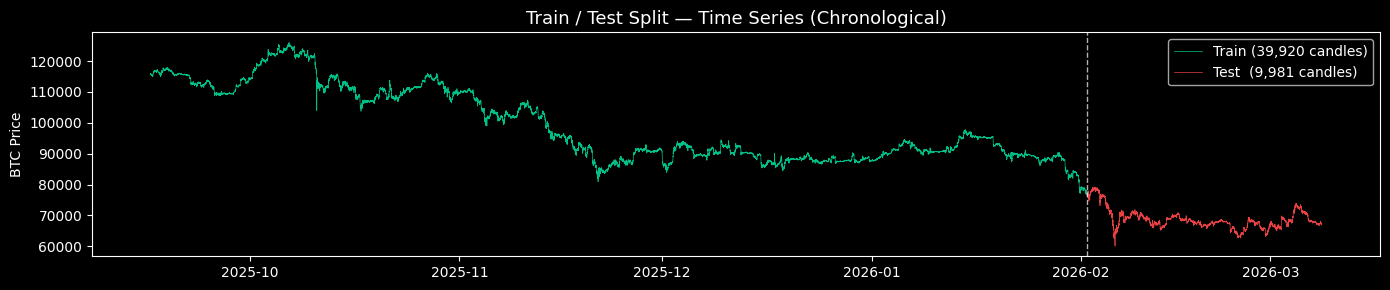

In [4]:
SPLIT_RATIO = 0.80    # 80% train, 20% test

split_idx = int(len(df) * SPLIT_RATIO)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_cls_train = y_cls.iloc[:split_idx]
y_cls_test  = y_cls.iloc[split_idx:]

y_reg_train = y_reg.iloc[:split_idx]
y_reg_test  = y_reg.iloc[split_idx:]

print('Train / Test Split:')
print(f'  Train size  : {len(X_train):,} candles')
print(f'  Test size   : {len(X_test):,}  candles')
print()
print(f'  Train from  : {X_train.index.min()}')
print(f'  Train to    : {X_train.index.max()}')
print(f'  Test  from  : {X_test.index.min()}')
print(f'  Test  to    : {X_test.index.max()}')
print()
print(f'  Train UP %  : {y_cls_train.mean()*100:.1f}%')
print(f'  Test  UP %  : {y_cls_test.mean()*100:.1f}%')

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(X_train.index, df.loc[X_train.index, 'close'],
        color='#00C087', linewidth=0.5, label=f'Train ({len(X_train):,} candles)')
ax.plot(X_test.index,  df.loc[X_test.index,  'close'],
        color='#E84142', linewidth=0.5, label=f'Test  ({len(X_test):,} candles)')
ax.axvline(X_test.index.min(), color='white', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Train / Test Split — Time Series (Chronological)', fontsize=13)
ax.set_ylabel('BTC Price')
ax.legend()
plt.tight_layout()
plt.show()


---
## ⚖️ Cell 5 — Feature Scaling

### Why scale?
Our features have very different ranges:
- RSI is always 0–100
- MACD might be ±500
- OBV might be in millions
- Returns are tiny decimals like 0.002

Without scaling, large-magnitude features dominate the model unfairly.

### Why StandardScaler?
`StandardScaler` transforms each feature to **mean=0, std=1**:
```
scaled_value = (value - mean) / std
```

### ⚠️ Critical rule — fit on TRAIN only:
```python
scaler.fit(X_train)      # learn mean/std from train only
scaler.transform(X_test) # apply same stats to test
```
If we fit on all data, test statistics leak into training = data leakage.

In [5]:
scaler = StandardScaler()

# fit ONLY on training data
X_train_sc = scaler.fit_transform(X_train)
# transform test using train's mean/std
X_test_sc  = scaler.transform(X_test)

print('Scaling done!')
print(f'  X_train_sc shape : {X_train_sc.shape}')
print(f'  X_test_sc  shape : {X_test_sc.shape}')
print()

# Verify: check a few feature stats after scaling
scaled_df = pd.DataFrame(X_train_sc, columns=feature_cols)
print('Sample scaled feature stats (should be ~mean=0, std=1):')
print(scaled_df[['rsi_14', 'macd_hist', 'bb_pct', 'return_1', 'volume_ratio']]
      .describe().round(3).to_string())


Scaling done!
  X_train_sc shape : (39920, 70)
  X_test_sc  shape : (9981, 70)

Sample scaled feature stats (should be ~mean=0, std=1):
          rsi_14  macd_hist     bb_pct   return_1  volume_ratio
count  39920.000  39920.000  39920.000  39920.000     39920.000
mean      -0.000     -0.000      0.000     -0.000        -0.000
std        1.000      1.000      1.000      1.000         1.000
min       -4.064    -22.917     -3.231    -51.638        -1.360
25%       -0.646     -0.426     -0.788     -0.396        -0.626
50%        0.028     -0.003      0.015      0.006        -0.266
75%        0.670      0.439      0.800      0.403         0.297
max        3.825      9.535      3.164     28.732        11.169


---
## 🌲 Cell 6 — Train XGBoost Classifier

### What is XGBoost?
XGBoost builds an **ensemble of decision trees** where each tree corrects
the mistakes of the previous one. This is called **gradient boosting**.

```
Tree 1: learns general patterns, makes errors
Tree 2: focuses on correcting Tree 1's errors
Tree 3: focuses on correcting Tree 2's errors
...
Tree 300: final prediction = weighted sum of all trees
```

### Key hyperparameters explained:
| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_estimators` | 300 | number of trees to build |
| `max_depth` | 5 | how deep each tree grows (deeper = more complex) |
| `learning_rate` | 0.05 | how much each tree contributes (small = more stable) |
| `subsample` | 0.8 | use 80% of rows per tree (prevents overfitting) |
| `colsample_bytree` | 0.8 | use 80% of features per tree (prevents overfitting) |

Training XGBoost Classifier...
✅ Classifier training complete!



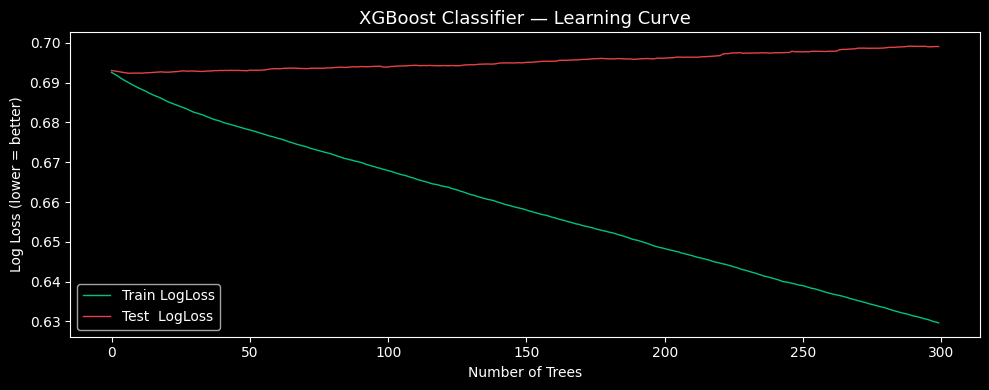

Best iteration  : 7
Best test loss  : 0.6924


In [6]:
print('Training XGBoost Classifier...')

clf = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1       # use all CPU cores
)

clf.fit(
    X_train_sc, y_cls_train,
    eval_set  = [(X_train_sc, y_cls_train),
                 (X_test_sc,  y_cls_test)],
    verbose   = False
)

print('✅ Classifier training complete!')
print()

# ── Plot training learning curve ──────────────────────────────────
results    = clf.evals_result()
train_loss = results['validation_0']['logloss']
test_loss  = results['validation_1']['logloss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, color='#00C087', linewidth=1, label='Train LogLoss')
ax.plot(test_loss,  color='#E84142', linewidth=1, label='Test  LogLoss')
ax.set_title('XGBoost Classifier — Learning Curve', fontsize=13)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Log Loss (lower = better)')
ax.legend()
plt.tight_layout()
plt.show()

# Optimal stopping point
best_iter = int(np.argmin(test_loss))
print(f'Best iteration  : {best_iter}')
print(f'Best test loss  : {test_loss[best_iter]:.4f}')


---
## 📊 Cell 7 — Classifier Evaluation

### Metrics explained:

**Accuracy** = correct predictions / total predictions
→ Simple but misleading if classes are imbalanced

**F1 Score** = harmonic mean of Precision and Recall
→ Better metric when we care about both false positives and false negatives

**ROC-AUC** = Area Under the ROC Curve
→ 0.5 = random guess, 1.0 = perfect, > 0.55 = meaningful signal in crypto

**Confusion Matrix:**
```
                Predicted DOWN  Predicted UP
Actual DOWN  [  True Negative   False Positive ]
Actual UP    [  False Negative  True Positive  ]
```

  XGBoost Classifier — Test Results
  Accuracy  : 0.5121  (51.21%)
  F1 Score  : 0.4732
  ROC-AUC   : 0.5196

Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.51      0.59      0.55      4976
      UP (1)       0.52      0.44      0.47      5005

    accuracy                           0.51      9981
   macro avg       0.51      0.51      0.51      9981
weighted avg       0.51      0.51      0.51      9981



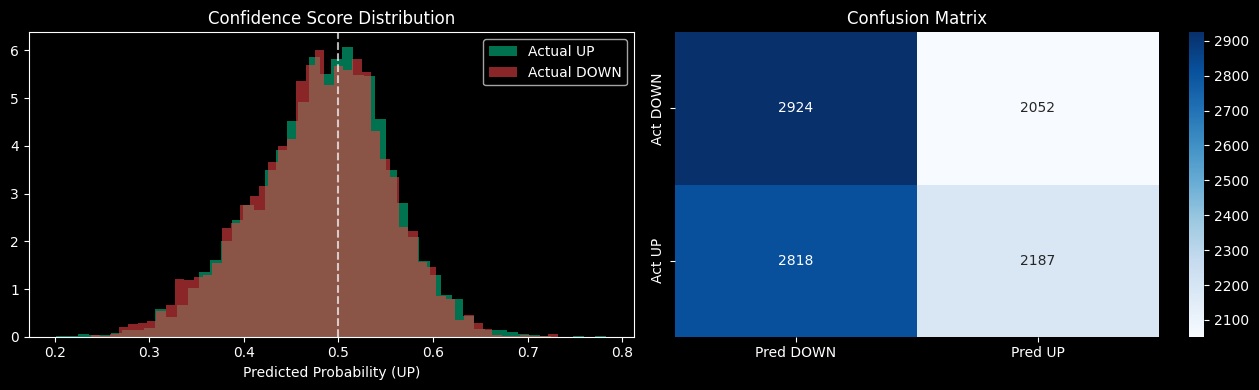


💡 Note: In crypto, even 52-53% accuracy is considered useful
   because small consistent edges compound over thousands of trades.


In [7]:
y_pred_cls = clf.predict(X_test_sc)
y_prob_cls = clf.predict_proba(X_test_sc)[:, 1]   # probability of UP

acc = accuracy_score(y_cls_test, y_pred_cls)
f1  = f1_score(y_cls_test, y_pred_cls)
roc = roc_auc_score(y_cls_test, y_prob_cls)

print('=' * 45)
print('  XGBoost Classifier — Test Results')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1 Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_cls_test, y_pred_cls,
                             target_names=['DOWN (0)', 'UP (1)']))

# Confidence score distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_prob_cls[y_cls_test == 1], bins=50,
             alpha=0.6, color='#00C087', label='Actual UP',   density=True)
axes[0].hist(y_prob_cls[y_cls_test == 0], bins=50,
             alpha=0.6, color='#E84142', label='Actual DOWN', density=True)
axes[0].axvline(0.5, color='white', linestyle='--', alpha=0.7)
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Predicted Probability (UP)')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_cls_test, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred DOWN','Pred UP'],
            yticklabels=['Act DOWN', 'Act UP'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

print()
print('💡 Note: In crypto, even 52-53% accuracy is considered useful')
print('   because small consistent edges compound over thousands of trades.')


---
## 📈 Cell 8 — Train XGBoost Regressor

Same architecture as the classifier but with a **regression objective**.
Instead of predicting a class (0/1), it predicts a continuous number (next price).

The key difference in XGBoost:
- Classifier uses `binary:logistic` objective internally
- Regressor uses `reg:squarederror` — it minimizes the squared error between
  predicted price and actual price.

Training XGBoost Regressor...
✅ Regressor training complete!



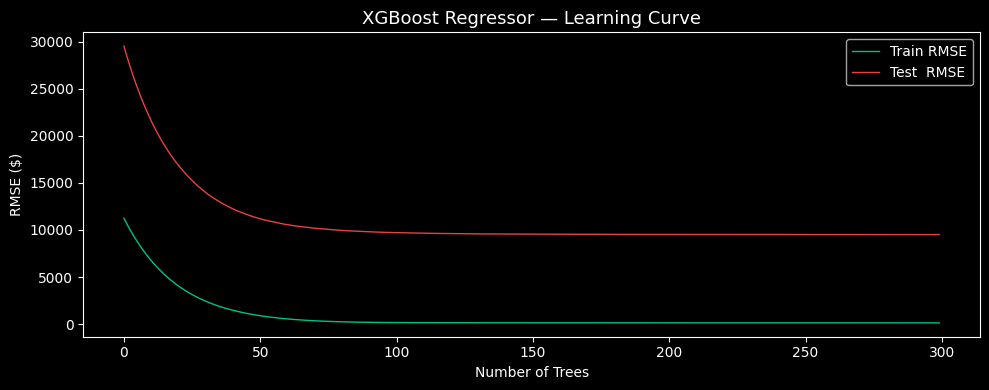

In [8]:
print('Training XGBoost Regressor...')

reg = xgb.XGBRegressor(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1
)

reg.fit(
    X_train_sc, y_reg_train,
    eval_set  = [(X_train_sc, y_reg_train),
                 (X_test_sc,  y_reg_test)],
    verbose   = False
)

print('✅ Regressor training complete!')
print()

# Learning curve
results    = reg.evals_result()
train_rmse = results['validation_0']['rmse']
test_rmse  = results['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_rmse, color='#00C087', linewidth=1, label='Train RMSE')
ax.plot(test_rmse,  color='#E84142', linewidth=1, label='Test  RMSE')
ax.set_title('XGBoost Regressor — Learning Curve', fontsize=13)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('RMSE ($)')
ax.legend()
plt.tight_layout()
plt.show()


---
## 📏 Cell 9 — Regressor Evaluation

### Metrics explained:

**RMSE (Root Mean Squared Error)**
→ Average prediction error in dollars. Lower = better.
→ Penalises large errors heavily (because of squaring).

**MAE (Mean Absolute Error)**
→ Average absolute error in dollars. More interpretable than RMSE.
→ `MAE = $50` means on average we're off by $50.

**MAPE (Mean Absolute Percentage Error)**
→ Error as a percentage of the actual price.
→ Scale-independent — useful when price changes over time.

  XGBoost Regressor — Test Results
  RMSE : $9,509.23
  MAE  : $8,991.92
  MAPE : 13.2993%

Interpretation:
  On average, predicted price is $8,991.92 away from actual price
  That is a 13.2993% error on the true price


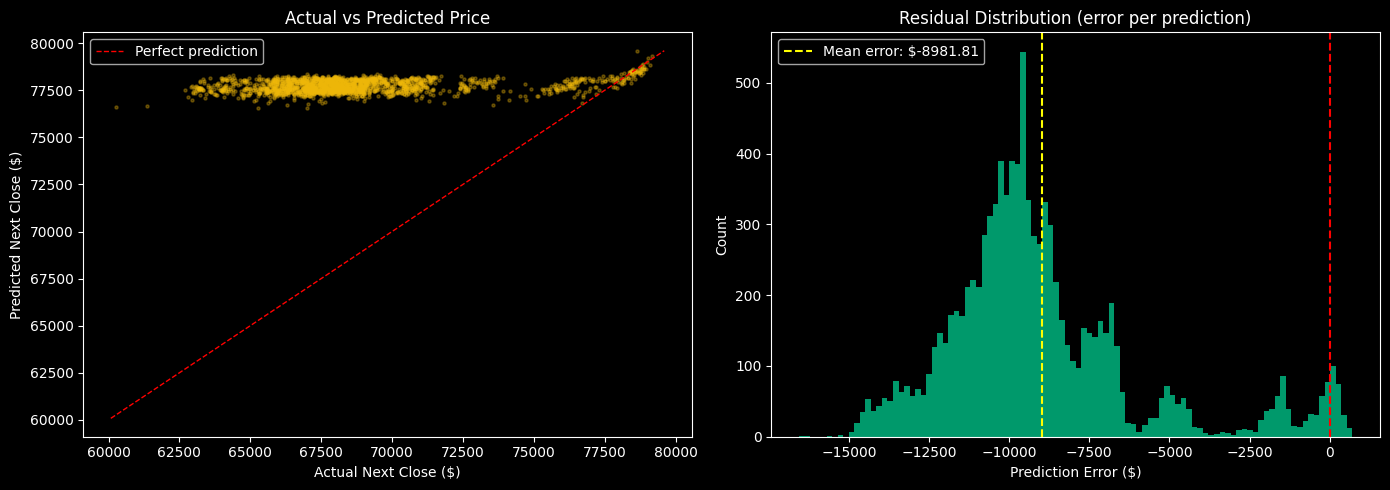

In [9]:
y_pred_reg = reg.predict(X_test_sc)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
mape = np.mean(np.abs((y_reg_test.values - y_pred_reg) / y_reg_test.values)) * 100

print('=' * 45)
print('  XGBoost Regressor — Test Results')
print('=' * 45)
print(f'  RMSE : ${rmse:,.2f}')
print(f'  MAE  : ${mae:,.2f}')
print(f'  MAPE : {mape:.4f}%')
print()
print('Interpretation:')
print(f'  On average, predicted price is ${mae:,.2f} away from actual price')
print(f'  That is a {mape:.4f}% error on the true price')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
sample_idx = np.random.choice(len(y_pred_reg), 2000, replace=False)
axes[0].scatter(y_reg_test.values[sample_idx], y_pred_reg[sample_idx],
                alpha=0.3, s=5, color='#F0B90B')
mn = min(y_reg_test.min(), y_pred_reg.min())
mx = max(y_reg_test.max(), y_pred_reg.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual Next Close ($)')
axes[0].set_ylabel('Predicted Next Close ($)')
axes[0].set_title('Actual vs Predicted Price')
axes[0].legend()

# Residual distribution
residuals = y_reg_test.values - y_pred_reg
axes[1].hist(residuals, bins=100, color='#00C087', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].axvline(residuals.mean(), color='yellow', linestyle='--',
                label=f'Mean error: ${residuals.mean():.2f}')
axes[1].set_xlabel('Prediction Error ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (error per prediction)')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 🏆 Cell 10 — Feature Importance

XGBoost tells us which features were most useful for prediction.
Importance = how often a feature was used to make splits across all trees.

This helps us:
1. Understand what drives price direction
2. Remove useless features in future iterations
3. Validate that the model learned sensible patterns

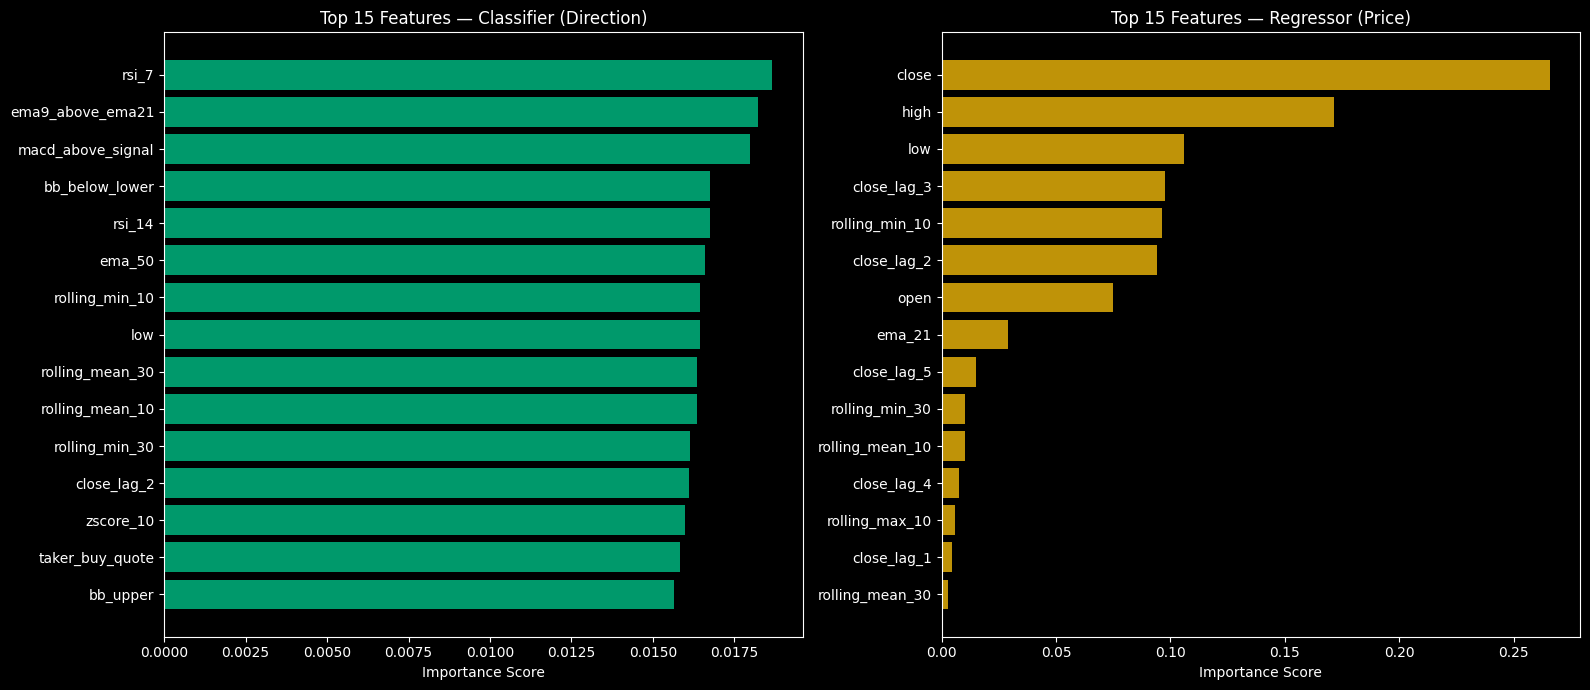

Top 10 Classifier Features:
          feature  importance
            rsi_7    0.018664
 ema9_above_ema21    0.018219
macd_above_signal    0.017990
   bb_below_lower    0.016769
           rsi_14    0.016761
           ema_50    0.016593
   rolling_min_10    0.016458
              low    0.016454
  rolling_mean_30    0.016355
  rolling_mean_10    0.016353


In [10]:
importance_cls = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : clf.feature_importances_
}).sort_values('importance', ascending=False)

importance_reg = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : reg.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Classifier importance
top_cls = importance_cls.head(15)
axes[0].barh(top_cls['feature'][::-1], top_cls['importance'][::-1],
             color='#00C087', alpha=0.8)
axes[0].set_title('Top 15 Features — Classifier (Direction)', fontsize=12)
axes[0].set_xlabel('Importance Score')

# Regressor importance
top_reg = importance_reg.head(15)
axes[1].barh(top_reg['feature'][::-1], top_reg['importance'][::-1],
             color='#F0B90B', alpha=0.8)
axes[1].set_title('Top 15 Features — Regressor (Price)', fontsize=12)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 10 Classifier Features:')
print(importance_cls.head(10).to_string(index=False))


---
## 💰 Cell 11 — Backtesting

### What is backtesting?
We simulate trading using our model's predictions on the test set
to see if our model would have made money in the past.

### Strategy:
```
If model predicts UP   → BUY  (long the market, earn the actual return)
If model predicts DOWN → FLAT (do nothing, return = 0)
```

This is called a **long-only strategy** — we never short sell.

### Key metrics:
- **Win rate** → % of trades that were profitable
- **Strategy return** → total % gain if we followed every signal
- **Market return** → what buy-and-hold would have returned
- **Sharpe ratio** → return / risk. > 1.0 is good, > 2.0 is excellent

> ⚠️ Backtesting does NOT account for trading fees, slippage, or liquidity.
> Real returns would be lower. This is an upper-bound estimate.

  Backtest Results (Test Period)
  Period          : 2026-02-01 → 2026-03-08
  Total trades    : 4,239
  Win rate        : 43.5%
  Avg win         : +0.1318%
  Avg loss        :  -0.1550%
  Market return   : -12.59%
  Strategy return : -72.33%
  Sharpe ratio    : -30.10
  Max drawdown    : -72.38%


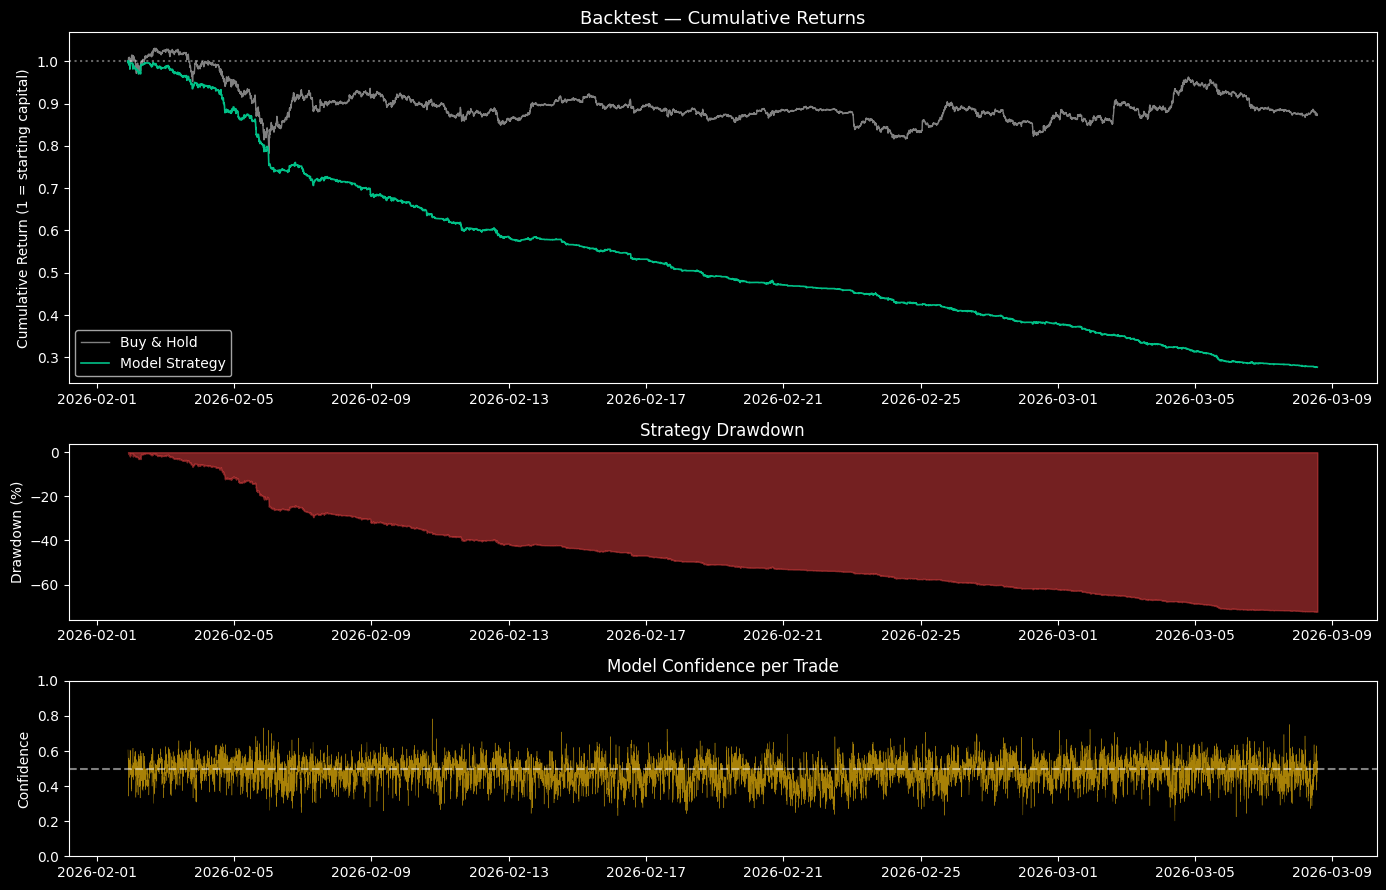

In [11]:
# Build test results DataFrame
bt = pd.DataFrame(index=X_test.index)
bt['actual_direction']    = y_cls_test.values
bt['predicted_direction'] = y_pred_cls
bt['confidence']          = y_prob_cls
bt['actual_close']        = y_reg_test.values
bt['predicted_close']     = y_pred_reg
bt['actual_return']       = df.loc[X_test.index, 'return_1'] / 100

# Strategy: long if model says UP, flat otherwise
bt['strategy_return'] = np.where(
    bt['predicted_direction'] == 1,
    bt['actual_return'],
    0.0
)

# Cumulative returns (compounded)
bt['cumulative_market']   = (1 + bt['actual_return']).cumprod()
bt['cumulative_strategy'] = (1 + bt['strategy_return']).cumprod()

# ── Metrics ────────────────────────────────────────────────────────
total_trades   = (bt['predicted_direction'] == 1).sum()
winning_trades = ((bt['predicted_direction'] == 1) &
                  (bt['actual_return'] > 0)).sum()
win_rate       = winning_trades / total_trades * 100
market_return  = (bt['cumulative_market'].iloc[-1]   - 1) * 100
strategy_return= (bt['cumulative_strategy'].iloc[-1] - 1) * 100
avg_win        = bt.loc[(bt['predicted_direction']==1) & (bt['actual_return']>0),
                        'actual_return'].mean() * 100
avg_loss       = bt.loc[(bt['predicted_direction']==1) & (bt['actual_return']<0),
                        'actual_return'].mean() * 100
# Annualised Sharpe (105120 5-min candles per year)
sr  = bt['strategy_return']
sharpe = (sr.mean() / sr.std()) * np.sqrt(105120) if sr.std() > 0 else 0

# Max drawdown
roll_max = bt['cumulative_strategy'].cummax()
drawdown = (bt['cumulative_strategy'] - roll_max) / roll_max * 100
max_dd   = drawdown.min()

print('=' * 50)
print('  Backtest Results (Test Period)')
print('=' * 50)
print(f'  Period          : {bt.index.min().date()} → {bt.index.max().date()}')
print(f'  Total trades    : {total_trades:,}')
print(f'  Win rate        : {win_rate:.1f}%')
print(f'  Avg win         : +{avg_win:.4f}%')
print(f'  Avg loss        :  {avg_loss:.4f}%')
print(f'  Market return   : {market_return:+.2f}%')
print(f'  Strategy return : {strategy_return:+.2f}%')
print(f'  Sharpe ratio    : {sharpe:.2f}')
print(f'  Max drawdown    : {max_dd:.2f}%')

# ── Plot ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1])

# Cumulative returns
ax1 = fig.add_subplot(gs[0])
ax1.plot(bt.index, bt['cumulative_market'],
         color='gray', linewidth=1, label='Buy & Hold')
ax1.plot(bt.index, bt['cumulative_strategy'],
         color='#00C087', linewidth=1.2, label='Model Strategy')
ax1.axhline(1.0, color='white', linestyle=':', alpha=0.4)
ax1.set_title('Backtest — Cumulative Returns', fontsize=13)
ax1.set_ylabel('Cumulative Return (1 = starting capital)')
ax1.legend()

# Drawdown
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.fill_between(bt.index, drawdown, 0,
                 color='#E84142', alpha=0.5)
ax2.set_title('Strategy Drawdown')
ax2.set_ylabel('Drawdown (%)')

# Confidence over time
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(bt.index, bt['confidence'], color='#F0B90B', linewidth=0.3, alpha=0.7)
ax3.axhline(0.5, color='white', linestyle='--', alpha=0.5)
ax3.set_title('Model Confidence per Trade')
ax3.set_ylabel('Confidence')
ax3.set_ylim(0, 1)

plt.tight_layout()
# plt.savefig('../data/processed/backtest_results.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 🔍 Cell 12 — Sample Predictions

Let's look at what the model actually outputs for a few candles —
exactly what `predict.py` will produce every 5 minutes in production.

In [ ]:
sample_bt = bt.tail(10).copy()
sample_bt['direction_label'] = sample_bt['predicted_direction'].map({1:'UP ▲', 0:'DOWN ▼'})
sample_bt['correct']         = (sample_bt['predicted_direction'] == sample_bt['actual_direction'])
sample_bt['price_error']     = (sample_bt['predicted_close'] - sample_bt['actual_close']).abs()

display_cols = ['actual_close','predicted_close','price_error',
                'confidence','direction_label','correct']

print('Last 10 predictions:')
print(sample_bt[display_cols].round(2).to_string())
print()
print('Output format in production (predict.py):')
last = sample_bt.iloc[-1]
print(f'''  {{
    "timestamp"       : "{sample_bt.index[-1]}",
    "predicted_price" : {last.predicted_close:.2f},
    "direction"       : "{'UP' if last.predicted_direction==1 else 'DOWN'}",
    "confidence"      : {last.confidence:.4f},
    "price_error_est" : {last.price_error:.2f}
  }}''')


---
## 💾 Cell 13 — Save Models

We save four files to the `models/` folder:
- `xgb_classifier.pkl` → trained direction model
- `xgb_regressor.pkl`  → trained price model
- `scaler.pkl`         → the fitted StandardScaler (must use same scaler at prediction time)
- `feature_cols.pkl`   → exact list of feature names in correct order

> ⚠️ We must save the scaler and feature list alongside the model.
> At prediction time, we must scale new data using the SAME mean/std the model was trained with.
> Using a different scaler would give completely wrong predictions.

In [ ]:
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(clf,          f'{MODEL_DIR}/xgb_classifier.pkl')
joblib.dump(reg,          f'{MODEL_DIR}/xgb_regressor.pkl')
joblib.dump(scaler,       f'{MODEL_DIR}/scaler.pkl')
joblib.dump(feature_cols, f'{MODEL_DIR}/feature_cols.pkl')

print('✅ All models saved!')
for fname in os.listdir(MODEL_DIR):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'   {fname:<30} {size:>8.1f} KB')

print()
print('Next step → predict.py will load these and run every 5 minutes!')


---
## ✅ Cell 14 — Reload & Verify

Always verify saved models load correctly and produce the same output.
This catches silent save/load errors before they hit production.

In [ ]:
# Load everything fresh
clf2    = joblib.load(f'{MODEL_DIR}/xgb_classifier.pkl')
reg2    = joblib.load(f'{MODEL_DIR}/xgb_regressor.pkl')
scaler2 = joblib.load(f'{MODEL_DIR}/scaler.pkl')
fcols2  = joblib.load(f'{MODEL_DIR}/feature_cols.pkl')

# Run prediction on last 1 test row
last_row    = X_test.iloc[[-1]][fcols2]
last_scaled = scaler2.transform(last_row)

pred_dir  = clf2.predict(last_scaled)[0]
pred_conf = clf2.predict_proba(last_scaled)[0, 1]
pred_price= reg2.predict(last_scaled)[0]

actual_price = y_reg_test.iloc[-1]
actual_dir   = y_cls_test.iloc[-1]

print('🔁 Loaded model verification:')
print(f'   Timestamp       : {X_test.index[-1]}')
print(f'   Predicted price : ${pred_price:,.2f}')
print(f'   Actual price    : ${actual_price:,.2f}')
print(f'   Price error     : ${abs(pred_price - actual_price):,.2f}')
print(f'   Predicted dir   : {"UP ▲" if pred_dir == 1 else "DOWN ▼"}')
print(f'   Actual dir      : {"UP ▲" if actual_dir == 1 else "DOWN ▼"}')
print(f'   Confidence      : {pred_conf:.4f}')
print(f'   Correct?        : {"✅ YES" if pred_dir == actual_dir else "❌ NO"}')
print()
print('✅ Models verified and ready for predict.py!')
